# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [ ]:
intro_text = """ЗДЕСЬ ОПИШИТЕ, КАК ВЫ СЕЙЧАС ПОНИМАЕТЕ ЗАДАЧУ ПРОГНОЗА
ВРЕМЕННЫХ РЯДОВ И ПОЧЕМУ ДЛЯ ЭТОГО ИСПОЛЬЗУЮТ LSTM. УПОМЯНИТЕ ТИПИЧНЫЕ
ОШИБКИ ПРОГНОЗА, КОТОРЫЕ ВЫ ОЖИДАЕТЕ УВИДЕТЬ НА СИНУСОИДЕ С ШУМОМ.

1. В обычной регрессии по независимым объектам время является еще одной независимой переменной,
а во временных рядах - это как обязательный признак, потому что модель должна учитывать сезонность, цикличность, шум и тп.
И, возможно, во временных рядах являются независимыми именно наблюдения, а не объекты, как в регрессии. Т.е. тут важен порядок, если все перемешать, то прогноз будет уже другой.

2. В MLP данные обрабатываются как независимые признаки, а не как последовательность. MLP не сможет увидеть что уже было или что там будет дальше.
LSTM в свою очередь запоминает всё с помощью внутреннего состояния. Это гораздо лучше для временных рядов.

3. Ожидаю увидеть смещение фазы (смотря какой сильный шум будет, конечно) и, скорее всего, затухание амлитуды в некоторых местах цикла."""
print(intro_text)

## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cuda


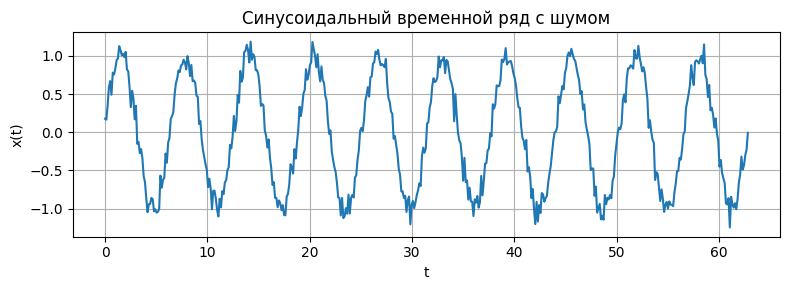

In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 0
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [3]:
series_comment = """ЗДЕСЬ ОПИШИТЕ, НАСКОЛЬКО ЯВНО В РЯДУ ВИДНА ПЕРИОДИЧНОСТЬ,
КАК СИЛЬНО ЕГО ИСКАЖАЕТ ШУМ И КАК БЫ ВЫ ОЦЕНИЛИ СЛОЖНОСТЬ ЭТОГО ПРИМЕРА
ПО СРАВНЕНИЮ С РЕАЛЬНЫМИ ВРЕМЕННЫМИ РЯДАМИ (ЭКОНОМИКА, СЕНСОРЫ И Т.П.).

Явная периодичность наблюдается, шум не сильно искажает синусоиду. Кривая похожа на какой-нибудь график трейдинга.
Но в большинстве случаев экономические/технические графики ведут себя иначе - синусоида может быть в некоторых местах цикла, но не постоянно.
Думаю, такой ряд может быть доставить трудности на реальных данных, потому что сейчас он достаточно предсказуем."""
print(series_comment)

ЗДЕСЬ ОПИШИТЕ, НАСКОЛЬКО ЯВНО В РЯДУ ВИДНА ПЕРИОДИЧНОСТЬ,
КАК СИЛЬНО ЕГО ИСКАЖАЕТ ШУМ И КАК БЫ ВЫ ОЦЕНИЛИ СЛОЖНОСТЬ ЭТОГО ПРИМЕРА
ПО СРАВНЕНИЮ С РЕАЛЬНЫМИ ВРЕМЕННЫМИ РЯДАМИ (ЭКОНОМИКА, СЕНСОРЫ И Т.П.).

Явная периодичность наблюдается, шум не сильно искажает синусоиду. Кривая похожа на какой-нибудь график трейдинга.
Но в большинстве случаев экономические/технические графики ведут себя иначе - синусоида может быть в некоторых местах цикла, но не постоянно.


## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [5]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [7]:
window_comment = """ЗДЕСЬ ОПИШИТЕ ПОСЛЕДСТВИЯ СЛИШКОМ МАЛОГО И СЛИШКОМ БОЛЬШОГО
ОКНА ДЛЯ LSTM-ПРОГНОЗА: КАК ЭТО ВЛИЯЕТ НА КАЧЕСТВО И НА СЛОЖНОСТЬ
ОБУЧЕНИЯ (ВРЕМЯ, ПЕРЕОБУЧЕНИЕ).

Думаю, что при маленьком размере окна модель не сможет захватить достаточно данных для обучения.
А при большом - переобучится."""
print(window_comment)

ЗДЕСЬ ОПИШИТЕ ПОСЛЕДСТВИЯ СЛИШКОМ МАЛОГО И СЛИШКОМ БОЛЬШОГО
ОКНА ДЛЯ LSTM-ПРОГНОЗА: КАК ЭТО ВЛИЯЕТ НА КАЧЕСТВО И НА СЛОЖНОСТЬ
ОБУЧЕНИЯ (ВРЕМЯ, ПЕРЕОБУЧЕНИЕ).

Думаю, что при маленьком размере окна модель не сможет захватить достаточно данных для обучения.


## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [8]:
input_size = 1
hidden_size = 32  # попробуйте другие значения при выполнении работы
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [ ]:
arch_comment = """ЗДЕСЬ ОБЪЯСНИТЕ, ПОЧЕМУ ДЛЯ ПРОГНОЗА ОДНОГО ШАГА МЫ БЕРЁМ
ИМЕННО ПОСЛЕДНЕЕ СКРЫТОЕ СОСТОЯНИЕ LSTM, И ЧТО ИЗМЕНИТСЯ ПРИ УВЕЛИЧЕНИИ
ЧИСЛА СЛОЁВ И РАЗМЕРА СКРЫТОГО СОСТОЯНИЯ.

Брать последнее скрытое состояние LSTM достаточно для прогноза одного следующего шага, потому что в этом в нем хранится информация о всех предыдущих шагах.
Но не прямо вся информация, а краткое понимание, что же там было тогда.
Так как реальные ряды менее предсказуемые, чем обучающие, то увеличение архитектуры поможет модели делать предсказания точнее.
"""
print(arch_comment)

## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 80  # в своей работе попробуйте и другое число эпох
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/80: train_loss=0.292286, test_loss=0.239479
Эпоха 10/80: train_loss=0.023003, test_loss=0.019866
Эпоха 20/80: train_loss=0.002096, test_loss=0.002204
Эпоха 30/80: train_loss=0.002100, test_loss=0.002184
Эпоха 40/80: train_loss=0.002012, test_loss=0.002188
Эпоха 50/80: train_loss=0.002096, test_loss=0.002360
Эпоха 60/80: train_loss=0.001954, test_loss=0.002120
Эпоха 70/80: train_loss=0.001954, test_loss=0.002102
Эпоха 80/80: train_loss=0.002019, test_loss=0.002218


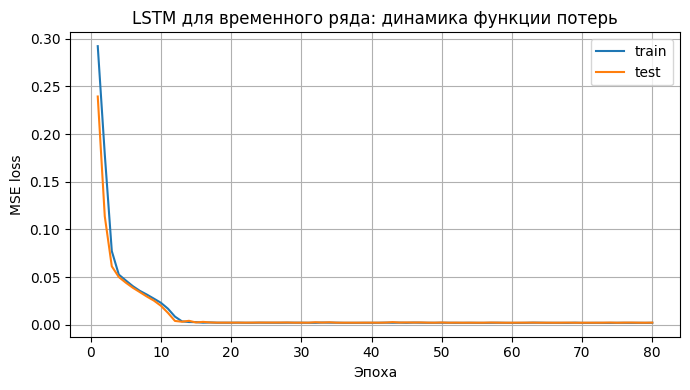

Финальные значения: train_loss=0.002019, test_loss=0.002218


In [10]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [ ]:
loss_comment = """ЗДЕСЬ ПРОКОММЕНТИРУЙТЕ ГРАФИКИ train/test loss: СШОДИТСЯ ЛИ
МОДЕЛЬ, ЕСТЬ ЛИ ПЕРЕОБУЧЕНИЕ И КАКИЕ ПРИМЕРНЫЕ ЧИСЛА LOSS ВЫ СЧИТАЕТЕ
РАЗУМНЫМИ ДЛЯ НОРМАЛИЗОВАННОЙ СИНУСОИДЫ.

Разрыва между train_loss и test_loss к концу обучения (уже на ~12 эпохе его не было) train_loss=0.002019, test_loss=0.002218.
"""
print(loss_comment)

## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


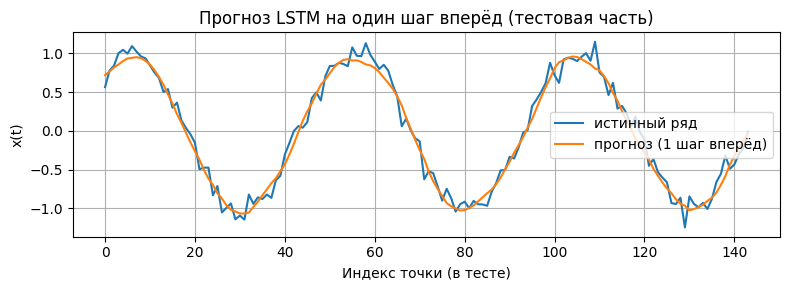

In [11]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [ ]:
one_step_comment = """ЗДЕСЬ ОПИШИТЕ КАЧЕСТВО ПРОГНОЗА НА ОДИН ШАГ ВПЕРЁД:
ГДЕ МОДЕЛЬ ПОПАДАЕТ ХОРОШО, А ГДЕ ОСОБЕННО ПРОМАХИВАЕТСЯ, И ПОЧЕМУ.
СРАВНИТЕ ЭТО С ОЖИДАНИЯМИ ИЗ ВВЕДЕНИЯ.

Модель хорошо попадает в фазу и амплитуду синусоиды, практически повторяя кривую, но не так шумно, а сглаженно.
Есть моменты, когда модель поворачивает раньше, чем движется истинный ряд, из-за этого видно небольшие выбросы, например, в районе 60-ой эпохи.
Скорее всего, модель понимает, что дальше кривая будет спускаться (так как синусоида все равно остается), поэтому так себя ведет.
"""
print(one_step_comment)

## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


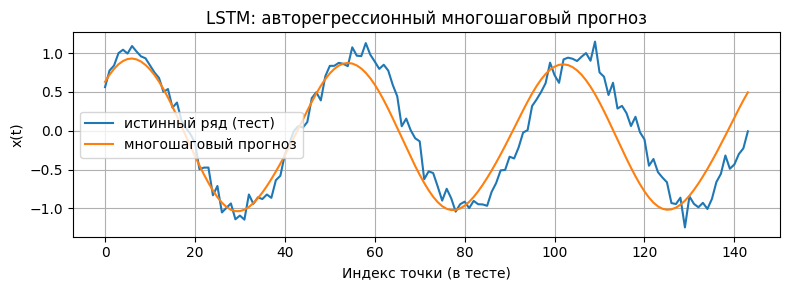

In [12]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [ ]:
multi_step_comment = """ЗДЕСЬ ОПИШИТЕ ОТЛИЧИЯ МЕЖДУ ОДНОШАГОВЫМ И МНОГОШАГОВЫМ
ПРОГНОЗОМ: ГДЕ НАЧИНАЕТ НАКАПЛИВАТЬСЯ ОШИБКА, КАК ЭТО ВИДНО НА ГРАФИКЕ,
И СОВПАЛО ЛИ ЭТО С ВАШИМИ ОЖИДАНИЯМИ.

Многошаговый прогноз уже не так качественно повторяет истинный ряд. Они как бы повторяют друг друга,
но модель будто в какой-то момент сместилась на небольшое расстояние и дальше двигалась неправильно.
Думал, что многошаговый прогноз будет наоборот качественнее повторять истинный ряд, но оказалось,
что с этим успешнее справился одношаговый прогноз."""
print(multi_step_comment)

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


Устройство: cuda


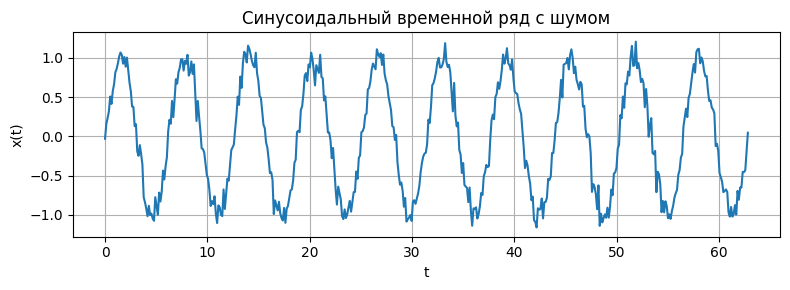

In [14]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 15
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Форма X_all: (480, 20)
Форма y_all: (480,)
Размер train: (336, 20)
Размер test : (144, 20)
Кол-во батчей в train_loader: 11


In [51]:
input_size = 1
hidden_size = 64  # попробуйте другие значения при выполнении работы
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Эпоха 1/100: train_loss=0.002065, test_loss=0.002342
Эпоха 10/100: train_loss=0.002059, test_loss=0.002334
Эпоха 20/100: train_loss=0.002058, test_loss=0.002335
Эпоха 30/100: train_loss=0.002058, test_loss=0.002332
Эпоха 40/100: train_loss=0.002057, test_loss=0.002336
Эпоха 50/100: train_loss=0.002057, test_loss=0.002333
Эпоха 60/100: train_loss=0.002057, test_loss=0.002334
Эпоха 70/100: train_loss=0.002059, test_loss=0.002332
Эпоха 80/100: train_loss=0.002059, test_loss=0.002335
Эпоха 90/100: train_loss=0.002056, test_loss=0.002334
Эпоха 100/100: train_loss=0.002056, test_loss=0.002335


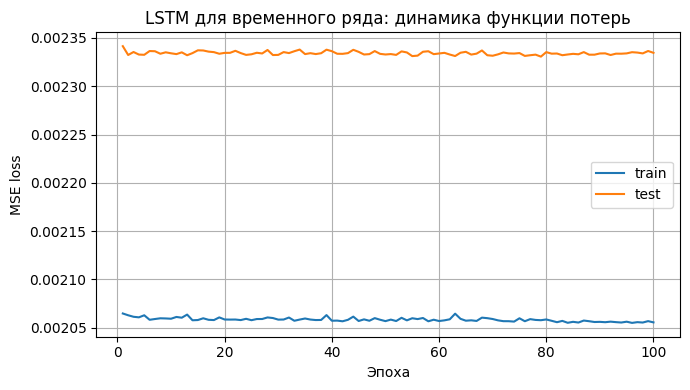

Финальные значения: train_loss=0.002056, test_loss=0.002335


In [56]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 100
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")


epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

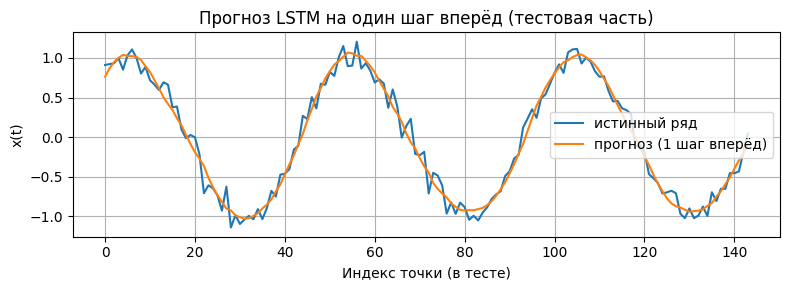

In [57]:
#### ОДНОШАГОВЫЙ ПРОГНОЗ ####

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

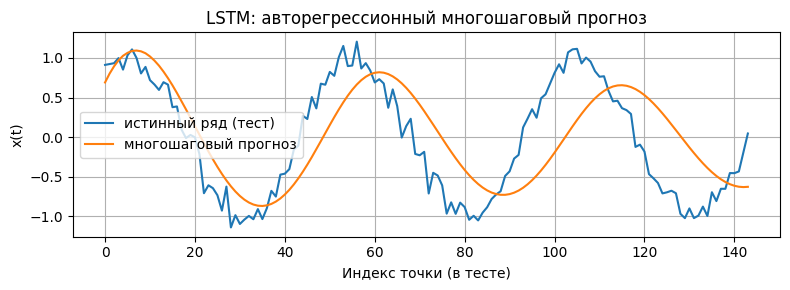

In [48]:
#### МНОГОШАГОВЫЙ ПРОГНОЗ ####

def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
final_summary = """КОГДА ВЫ ПРОВЕДЁТЕ СВОИ ЭКСПЕРИМЕНТЫ (ДРУГИЕ window_size,
РАЗМЕРЫ LSTM И ЧИСЛО ЭПОХ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ, ЧТОБЫ СФОРМУЛИРОВАТЬ
ИТОГОВЫЕ ВЫВОДЫ: КАКИЕ НАСТРОЙКИ ОКАЗАЛИСЬ ОПТИМАЛЬНЫМИ, КАК ВЕДЁТ СЕБЯ
МНОГОШАГОВЫЙ ПРОГНОЗ И КАКИЕ ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО НАСТРОЙКЕ
LSTM ДЛЯ ВРЕМЕННЫХ РЯДОВ ВЫ ДЛЯ СЕБЯ СДЕЛАЛИ.


При маленьком window_size (5) лоссы немного увеличились (с 0.002 до 0.004), одношаговый прогноз стал точнее повторять истинный ряд, уже не так сглаженно.
А многошаговый прогноз вообще перестал работать, амплитуда затихла практически сразу, а с ~80-ой эпохи вообще ушла практически в стабильность.

При большом window_size (300) между лоссами появился больший разрыв train_loss=0.002720, test_loss=0.001434. Хотя можно ли назвать это разрывом при таких маленьких значениях?
Но на графике там каждый микро-скачок видно, и кривые уже не кажутся такими стабльно убывающими, как обычно.
Одношаговый прогноз сглаженный, идет по синусоиде. Многошаговый также, не смещается.

Увеличив hidden_dim до 128, одношаговый прогноз уже больше подстраивается под кривую, покрывая шум.
Многоразовый - смещается вперед, амплитуда уменьшается.

В итоге самым главным параметром в настройке можно выделить размер окна. Мне кажется, его можно подобрать настолько точно, чтобы кривая практически полностью повторяла истинный ряд (но это лишь догадки).
"""
print(final_summary)

КОГДА ВЫ ПРОВЕДЁТЕ СВОИ ЭКСПЕРИМЕНТЫ (ДРУГИЕ window_size,
РАЗМЕРЫ LSTM И ЧИСЛО ЭПОХ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ, ЧТОБЫ СФОРМУЛИРОВАТЬ
ИТОГОВЫЕ ВЫВОДЫ: КАКИЕ НАСТРОЙКИ ОКАЗАЛИСЬ ОПТИМАЛЬНЫМИ, КАК ВЕДЁТ СЕБЯ
МНОГОШАГОВЫЙ ПРОГНОЗ И КАКИЕ ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО НАСТРОЙКЕ
LSTM ДЛЯ ВРЕМЕННЫХ РЯДОВ ВЫ ДЛЯ СЕБЯ СДЕЛАЛИ.


При маленьком window_size (5) лоссы немного увеличились (с 0.002 до 0.004), одношаговый прогноз стал точнее повторять истинный ряд, уже не так сглаженно.
